In [21]:
from setup import setup,scale_features
from utils import apply_isolation_forest, plot_isolation_forest_pca, plot_isolation_forest_scores
import pandas as pd
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [22]:
features = setup()

scaled_features = scale_features(features)

featues_gmm = pd.DataFrame(scaled_features, index=features.index, columns=features.columns)

[*********************100%***********************]  9 of 9 completed


Ticker           GLD       IWM       QQQ       SHY       SPY       TLT  \
Date                                                                     
2020-01-03  0.013269 -0.003921 -0.009160  0.000827 -0.007572  0.015401   
2020-01-06  0.010490  0.001332  0.006443 -0.000355  0.003815 -0.005679   
2020-01-07  0.003935 -0.003326 -0.000139  0.000000 -0.002812 -0.004915   
2020-01-08 -0.007502  0.003095  0.007516 -0.000472  0.005329 -0.006611   
2020-01-09 -0.005652  0.001210  0.008474  0.000118  0.006781  0.003510   

Ticker           XLE       XLF       XLK  
Date                                      
2020-01-03 -0.002971 -0.010617 -0.011243  
2020-01-06  0.007781 -0.000651  0.002383  
2020-01-07 -0.002628 -0.006508 -0.000432  
2020-01-08 -0.016472  0.006551  0.010701  
2020-01-09  0.007369  0.006183  0.011336  


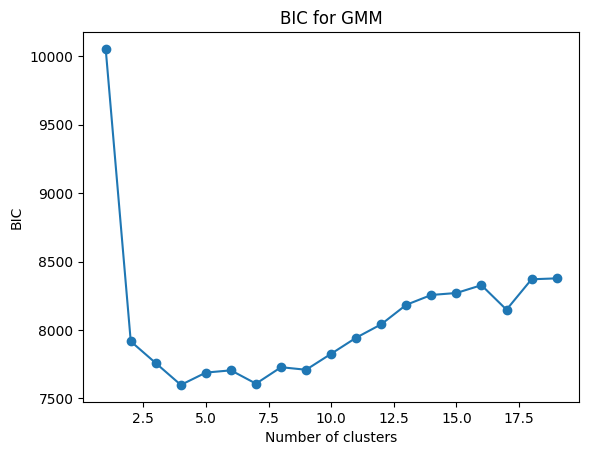

In [23]:
#calc bayesian information criterion for GMM
bic = []
for k in range(1, 20):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(scaled_features)
    bic.append(gmm.bic(scaled_features))

plt.plot(range(1, 20), bic, marker='o')
plt.title('BIC for GMM')
plt.xlabel('Number of clusters')
plt.ylabel('BIC')
plt.show()


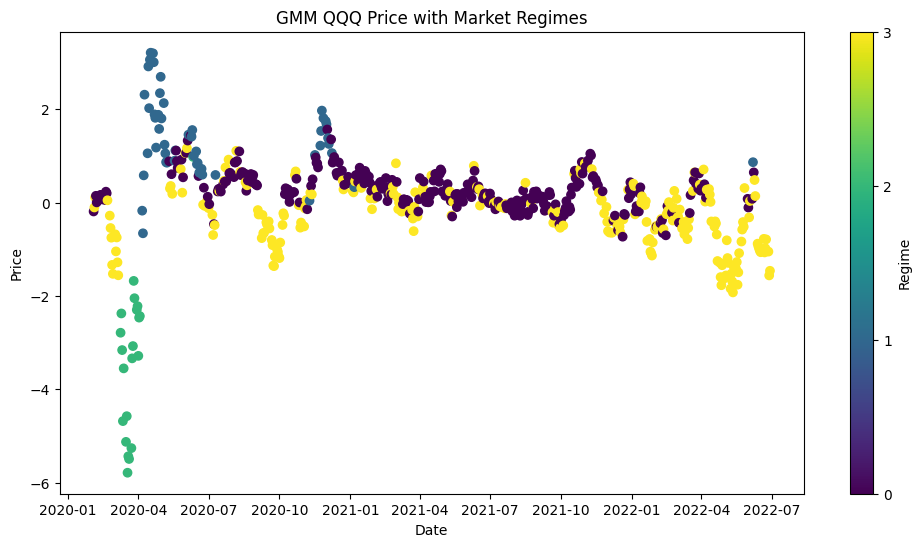

In [24]:
# run GMM clustering
gmm = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
regime = gmm.fit_predict(scaled_features)

featues_gmm['regime'] = regime

# plot regimes
plt.figure(figsize=(12, 6))
plt.scatter(features.index, featues_gmm["avg_return"], c=regime, cmap='viridis', marker='o')
plt.title('GMM QQQ Price with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Price')
plt.colorbar(label='Regime', ticks=range(4))
plt.show()

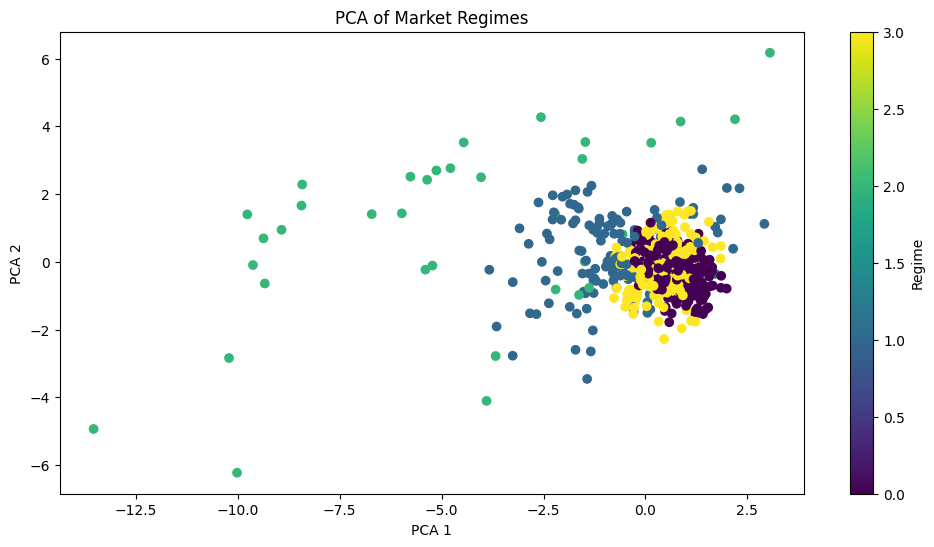

In [25]:
pca = PCA(n_components=3)
features_pca = pca.fit_transform(scaled_features)
regime = gmm.fit_predict(features_pca)

scaled_features_pca = featues_gmm.copy()
scaled_features_pca["regime"] = regime

plt.figure(figsize=(12, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=regime, cmap='viridis', marker='o')
plt.title('PCA of Market Regimes')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Regime')
plt.show()

    

In [26]:
scaled_features_pca.assign(regime=regime).groupby('regime').mean()

,volatility,avg_return,dispersion,correlation,equity_bond_spread,drawdown,vol_change
regime,,,,,,,
0,-0.213206,0.361061,-0.277614,-0.463871,0.310394,0.375661,-0.122889
1,0.238252,-0.335102,0.419703,0.471609,-0.218894,-0.535542,0.033370
2,3.004567,-1.605518,2.536522,0.192099,0.323476,-2.293876,0.905790
3,-0.470601,0.029328,-0.404854,0.320285,-0.375261,0.289890,-0.027916


In [27]:
scaled_features_pca["future_return"] = scaled_features_pca["avg_return"].shift(-1)
scaled_features_pca.assign(regime=regime).groupby('regime')["future_return"].mean()

regime
0    0.344693
1   -0.320445
2   -1.484772
3    0.017727
Name: future_return, dtype: float64

In [28]:
labels, best_params, score = apply_isolation_forest(scaled_features)
print(f"Best contamination={best_params[0]}, n_estimators={best_params[1]}")
print(f"Silhouette Score: {score:.4f}")
print(f"Normal: {(labels == 1).sum()}, Anomalies: {(labels == -1).sum()}")

Best contamination=0.01, n_estimators=100
Silhouette Score: 0.7562
Normal: 600, Anomalies: 7


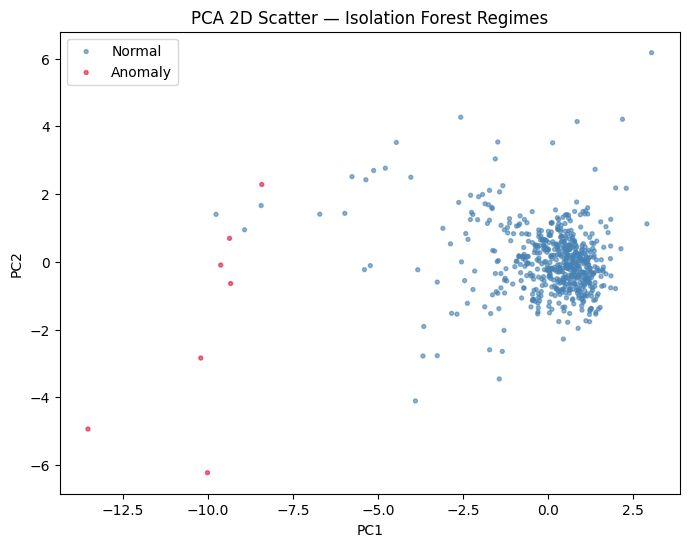

In [29]:
plot_isolation_forest_pca(scaled_features, labels)

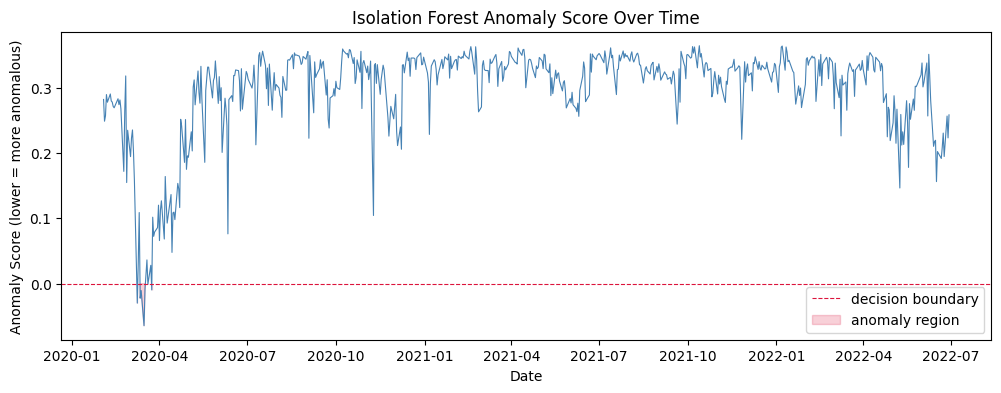

In [30]:
plot_isolation_forest_scores(scaled_features, features.index, best_params[0], best_params[1])